In [19]:
import os
os.chdir('c:\\Users\\Mikael Huff\\Documents\\Training')
os.getcwd()

'c:\\Users\\Mikael Huff\\Documents\\Training'

In [20]:
E = 100
B = 1
temp = 1-2*E
numer_sqrt = (temp**2 + 8 * B)**.5
print(temp, numer_sqrt)
result = (temp + numer_sqrt)/2
print(B+result)

-199 199.02009948746382
1.010049743731912


## Artificial Neural Network with Variable Architecture and Back Propagation

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
from matplotlib.colors import ListedColormap
cmap_bold = ListedColormap(['#FF0000','#00FF00','#0000ff'])
cmap_light = ListedColormap(['#FFbbbb','#bbffbb','#bbbbff'])

In [23]:
# Activations
def linear(H):
    return H

def sigmoid(H):
    return 1/(1+np.exp(-H))

def ReLU(H):
    return H*(H>0)

def softmax(H):
    exp_H = np.exp(H)
    return exp_H/exp_H.sum(axis=1,keepdims=True)

# Loss Functions
def cross_entropy(Y, P_hat):
    return -(1/len(Y))*np.sum(Y*np.log(P_hat))

def OLS(Y, Y_hat):
    return (1/(2*len(Y))*np.sum((Y-Y_hat)**2))

# Useful Functions
def one_hot(y):
    N = len(y)
    K = len(set(y))
    Y = np.eye(K)[y.reshape(-1)]
    return Y


def accuracy(y, y_hat):
    return np.mean(y==y_hat)

def R2(y, y_hat):
    return 1-np.sum((y-y_hat)**2)/np.sum((y-y.mean())**2)

### Derivatives of Activations

In [24]:
def derivative(Z, a):
    if a == linear:
        return 1
    elif a == sigmoid:
        return Z*(1-Z)
    elif a == np.tanh:
        return 1-Z**2
    elif a == ReLU:
        return (Z>0).astype(int)
    else:
        ValueError('Unknown Activation Function for Derivation')
    
    

## ANN Class

In [29]:
class ANN():
    def __init__(self, architecture, activations=None, mode=0):
        self.architecture = architecture
        self.activations = activations
        self.mode = mode
        self.L = len(architecture) + 1

    def fit(self, X, y, eta=1e-3, epochs=1e3, show_curve=True):
        epochs = int(epochs)

           
        N, D = X.shape
        if self.mode:  # regression (mode == 1)
            Y = y 
            K = 1
            loss_func = OLS
            out_act = linear
        else: # classifier (mode == 0)
            Y = one_hot(y)
            K = Y.shape[1]  
            loss_func = cross_entropy
            out_act = softmax   

        # Intialize Weights and Biases
        layers = zip([D] + self.architecture,self.architecture+[K])
        self.W = {l:np.random.randn(M[0], M[1]) for l, M in enumerate(layers, 1)}
        self.B = {l:np.random.randn(M) for l, M in enumerate(self.architecture+[K],1)}
        
        # Define Activations
        if self.activations is None:
            self.a = {l:ReLU for l in range(1, self.L)}
        else:
            self.a = {l:act for l, act in enumerate(self.activations, 1)}
        self.a[self.L] = out_act
        
        # Loss Container
        J = np.zeros(epochs)


        # Gradient Descent Progression
        for epoch in range(epochs):
            self.__forward__(X)
            J[epoch] = loss_func(Y, self.Z[self.L])
            # Weight Update Rules for Layer 2
            dH = (1/N) * (self.Z[self.L]-Y)
            for l in sorted(self.W.keys(), reverse=True):
                dW = self.Z[l-1].T @ dH
                dB = dH.sum(axis=0)
                self.W[l] -= eta * dW
                self.B[l] -= eta * dB

                if l > 1:
                    dZ = dH @ self.W[l].T
                    dH = dZ * derivative(self.Z[l-1], self.a[l-1])

        if show_curve:
            plt.figure()
            plt.plot(J)
            plt.xlabel('epochs')
            plt.ylabel('$\\mathcal{L}$')
            plt.title('Training Curve')
            plt.show()

    def __forward__(self, X):
        self.Z = {0:X}
        for l in sorted(self.W.keys()):
            self.Z[l] = self.a[l](self.Z[l-1] @ self.W[l] + self.B[l])


    def predict(self, X):
        self.__forward__(X)
        if self.mode:
            return self.Z[self.L]
        else:
            return self.Z[self.L].argmax(axis=1)



### Implementation of ANN Class

In [38]:
def main_class():
    D = 2
    K = 3
    N = int(K*1e3)

    X0 = np.random.randn((N//K),D) + np.array([2,2])
    X1 = np.random.randn((N//K),D) + np.array([0,-2])
    X2 = np.random.randn((N//K),D) + np.array([-2,2])
    X = np.vstack((X0,X1,X2))

    y = np.array([0]*(N//K) + [1]*(N//K) + [2]*(N//K))

    plt.figure()
    plt.scatter(X[:,0],X[:,1], c=y, s=6, alpha=0.6)

    my_ann_classifier = ANN(architecture=[6,5,4], activations=[np.tanh, ReLU, ReLU])
    my_ann_classifier.fit(X, y, eta=1e-2, epochs=7e3)
    y_hat = my_ann_classifier.predict(X)
    # print(my_ann_classifier.W)
    # print(my_ann_classifier.B)
    print(f"Training Accuracy: {accuracy(y,y_hat):.4f}")

    x1 = np.linspace(X[:,0].min() - 1, X[:,0].max() + 1, 1000)
    x2 = np.linspace(X[:,1].min() - 1, X[:,1].max() + 1, 1000)
    xx1, xx2 = np.meshgrid(x1, x2)
    Z = my_ann_classifier.predict(np.c_[xx1.ravel(),xx2.ravel()]).reshape(*xx1.shape)
    plt.figure()
    plt.pcolormesh(xx1, xx2, Z, cmap = cmap_light)
    plt.scatter(X[:,0], X[:,1], c = y, cmap = cmap_bold,alpha=0.2)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    plt.show()
    plt.figure()
    plt.scatter(X[:,0],X[:,1],c=y_hat,s=6)

 

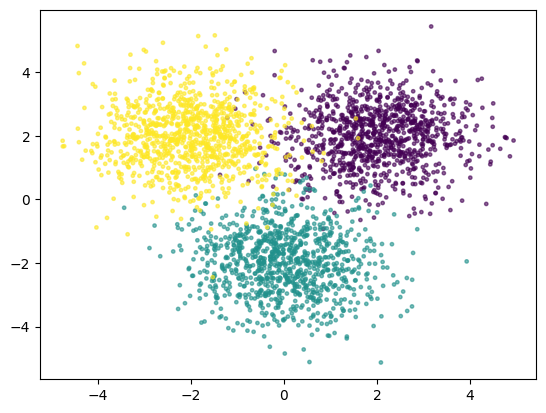

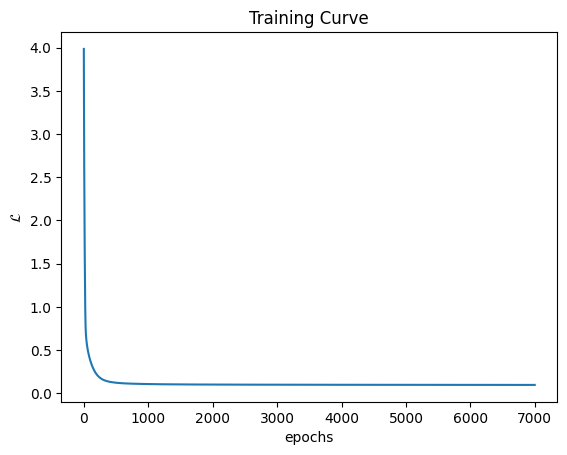

Training Accuracy: 0.9697


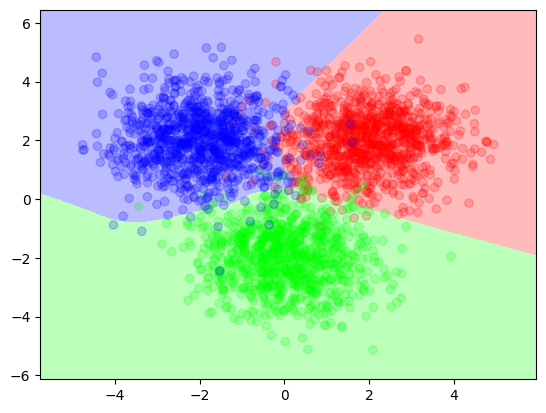

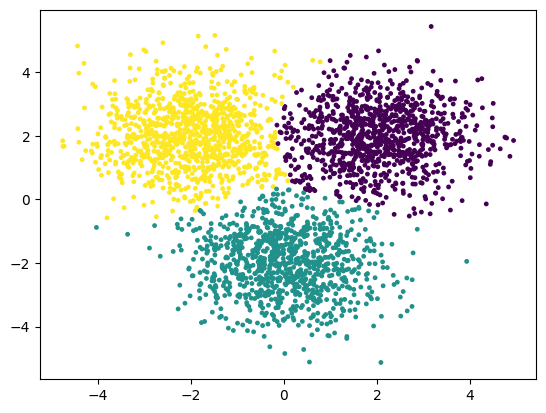

In [39]:
if __name__ == "__main__":
    main_class()

In [41]:
4**.25

1.4142135623730951

In [43]:
16**.25

2.0

In [45]:
64**.25

2.8284271247461903

In [53]:
import pandas as pd

def createDataframe(student_data: list[list[int]]) -> pd.DataFrame:

    df = pd.DataFrame(student_data, columns=['student_id','age'])
    return df

student_data = [[1,15],[2,11],[3,11],[4,20]]
createDataframe(student_data)

,student_id,age
0,1,15
1,2,11
2,3,11
3,4,20


In [ ]:
a = [1,2,4,0,3,0]
a.remove(0) 
a

[1, 2, 4, 3, 0]